# 1D steady single-phase water cooling model for a cold plate

This notebook-style Python script models:
- 1D coolant heating along a straight channel
- 1D axial conduction in an equivalent cold-plate solid
- Conjugate convection between the solid and water
- Ambient convection from the external top surface
- A localized 600 W heater
- Darcy-Weisbach pressure drop and channel velocity

The file uses `# %%` cell markers so PyCharm can run it as notebook-like cells or
convert it to a Jupyter notebook. Edit the GEOMETRY block to match the CAD model.

Important limitation: the supplied Ansys report does not contain channel length,
width, height, solid thicknesses, heater footprint, or number of parallel channels.
The 32 channel dimensions and AlN heater geometry supplied after the report are used below.
Copper thickness remains an editable assumption. Material properties
and boundary conditions are taken directly from the report.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

## 1. Inputs

In [11]:
# ------------------------------
# GEOMETRY: replace with CAD data
# ------------------------------
L = 0.025                 # fluid-path length [m]
channel_width = 0.4067e-3 # each fluid-path width [m]
channel_height = 5.5008e-3 # each fluid-path height [m]
number_of_channels = 32   # identical parallel fluid paths

plate_width = 0.048       # heater/cold-plate width across the channels [m]
t_copper = 0.0030         # effective copper thickness carrying axial heat [m]
t_AlN = 0.0030            # aluminium-nitride heater thickness [m]
heater_length = 0.030     # AlN heater length in flow direction [m]
heater_center_x = L / 2   # heater center position [m]
heater_width = 0.048      # AlN heater width across channels [m]

# Wetted perimeter uses all four walls of each rectangular fluid path.
# If the fins have open/shared boundaries, revise this definition accordingly.
flow_area_one = channel_width * channel_height
wetted_perimeter_one = 2.0 * (channel_width + channel_height)
flow_area_total = number_of_channels * flow_area_one
wetted_perimeter_total = number_of_channels * wetted_perimeter_one
hydraulic_diameter = 4.0 * flow_area_one / wetted_perimeter_one

# Orientation assumption: 30 mm is along the flow direction and 48 mm is
# across the 32 fluid paths. Since the fluid paths are only 25 mm long, the
# entire modeled flow length is under the heater.

# ------------------------------
# ANSYS BOUNDARY CONDITIONS
# ------------------------------
Q_total = 2500.0           # total heater power [W]
m_dot_total = 0.050       # total water mass flow rate [kg/s]
T_in_C = 10.0             # inlet and initial water temperature [degC]
h_ambient = 10.0          # external natural convection coefficient [W/m2-K]
T_ambient_C = 22.0        # ambient convection temperature [degC]

# ------------------------------
# MATERIAL PROPERTIES FROM REPORT
# ------------------------------
# Water, constant properties
rho_w = 997.0             # [kg/m3]
mu_w = 0.00089            # [Pa.s]
k_w = 0.603               # [W/m-K]
cp_w = 4.18e3             # 4.18 kJ/kg-K -> [J/kg-K]

# Copper C10100, hard
rho_cu = 8940.0           # [kg/m3]
k_cu = 397.0              # [W/m-K]
cp_cu = 0.383e3           # [J/kg-K]

# Aluminium nitride
rho_AlN = 3300.0          # [kg/m3]
k_AlN = 170.0             # [W/m-K]
cp_AlN = 0.74e3           # [J/kg-K]

# ------------------------------
# NUMERICAL CONTROLS
# ------------------------------
N = 301                   # axial control volumes
max_iterations = 500
convergence_tolerance = 1.0e-8  # maximum temperature change [K]
relaxation = 0.65

# Choose heat-transfer correlation.
# 'auto': laminar Nu=4.36; turbulent Gnielinski; linear transition blend.
correlation = 'auto'

# Optional calibration multiplier. Keep at 1.0 for prediction.
h_multiplier = 1.0

## 2. Flow and heat-transfer correlations

In [12]:
def friction_factor_and_nusselt(Re, Pr):
    """Return Darcy friction factor, Nusselt number, and regime label.

    Laminar assumptions: hydrodynamically/thermally developed flow,
    constant wall heat flux, Nu = 4.36, Darcy f = 64/Re.
    Turbulent assumptions: smooth channel, Petukhov friction factor and
    Gnielinski Nusselt correlation. The 2300-3000 region is blended.
    """
    Re_safe = max(float(Re), 1.0e-12)
    f_lam = 64.0 / Re_safe
    Nu_lam = 4.36

    # Smooth-pipe Petukhov expression used by Gnielinski.
    f_turb = (0.79 * np.log(max(Re_safe, 3000.0)) - 1.64) ** -2
    Nu_turb = ((f_turb / 8.0) * (max(Re_safe, 3000.0) - 1000.0) * Pr /
               (1.0 + 12.7 * np.sqrt(f_turb / 8.0) * (Pr ** (2.0 / 3.0) - 1.0)))

    if Re_safe <= 2300.0:
        return f_lam, Nu_lam, 'laminar'
    if Re_safe >= 3000.0:
        return f_turb, Nu_turb, 'turbulent'

    blend = (Re_safe - 2300.0) / 700.0
    f = (1.0 - blend) * f_lam + blend * f_turb
    Nu = (1.0 - blend) * Nu_lam + blend * Nu_turb
    return f, Nu, 'transition'


velocity = m_dot_total / (rho_w * flow_area_total)
m_dot_per_channel = m_dot_total / number_of_channels
Re = rho_w * velocity * hydraulic_diameter / mu_w
Pr = cp_w * mu_w / k_w
f_D, Nu, flow_regime = friction_factor_and_nusselt(Re, Pr)
h_water = h_multiplier * Nu * k_w / hydraulic_diameter

# Darcy-Weisbach straight-channel pressure loss. Minor losses are not included.
delta_p_friction = f_D * (L / hydraulic_diameter) * 0.5 * rho_w * velocity**2

print('Flow quantities')
print(f'  Total flow area       = {flow_area_total:.6e} m2')
print(f'  Hydraulic diameter    = {hydraulic_diameter:.6f} m')
print(f'  Mean velocity         = {velocity:.4f} m/s')
print(f'  Reynolds number       = {Re:.0f} ({flow_regime})')
print(f'  Prandtl number        = {Pr:.3f}')
print(f'  Darcy friction factor = {f_D:.5f}')
print(f'  Nusselt number        = {Nu:.3f}')
print(f'  Water-side h          = {h_water:.1f} W/m2-K')
print(f'  Friction pressure drop= {delta_p_friction:.1f} Pa')

Flow quantities
  Total flow area       = 7.158961e-05 m2
  Hydraulic diameter    = 0.000757 m
  Mean velocity         = 0.7005 m/s
  Reynolds number       = 594 (laminar)
  Prandtl number        = 6.169
  Darcy friction factor = 0.10768
  Nusselt number        = 4.360
  Water-side h          = 3471.2 W/m2-K
  Friction pressure drop= 869.5 Pa


## 3. Coupled 1D conjugate thermal model

The solid centerline temperature is solved with axial conduction. Each axial
control volume loses heat to water through a series resistance consisting of:

1. AlN through-thickness conduction over the projected plate width
2. Copper through-thickness conduction over the projected plate width
3. Internal water-side convection over the channel wetted perimeter

The external top surface also exchanges heat with the 22 degC ambient using
h = 10 W/m2-K. The two axial ends are treated as adiabatic.

In [13]:
x = np.linspace(0.0, L, N)
dx = x[1] - x[0]

# Effective axial conduction area. Copper and AlN conduct in parallel axially.
A_axial = plate_width * t_copper + heater_width * t_AlN
kA_axial = k_cu * plate_width * t_copper + k_AlN * heater_width * t_AlN

# Conductance to coolant per unit length [W/(m.K)].
# For a detailed model, replace this resistance network with the actual layer stack.
R_AlN_per_length = t_AlN / (k_AlN * heater_width)
R_Cu_per_length = t_copper / (k_cu * plate_width)
R_conv_per_length = 1.0 / (h_water * wetted_perimeter_total)
UA_water_per_length = 1.0 / (R_AlN_per_length + R_Cu_per_length + R_conv_per_length)

# Ambient conductance per unit length from top projected area.
UA_ambient_per_length = h_ambient * plate_width

# Localized, uniform line heat input [W/m], normalized exactly to 600 W.
heater_mask = np.abs(x - heater_center_x) <= heater_length / 2.0
q_line = np.zeros_like(x)
q_line[heater_mask] = 1.0
q_line *= Q_total / np.trapz(q_line, x)

# Initial coolant estimate: ideal rise if all 600 W enters the water.
T_water = T_in_C + (Q_total / (m_dot_total * cp_w)) * x / L
T_solid = np.full(N, T_in_C + 20.0)

# Control-volume lengths: half cells at boundaries.
cv_length = np.full(N, dx)
cv_length[0] = dx / 2.0
cv_length[-1] = dx / 2.0

for iteration in range(1, max_iterations + 1):
    # Build linear solid energy equation:
    # axial conduction + coolant loss + ambient loss = heater input.
    A = lil_matrix((N, N), dtype=float)
    b = np.zeros(N)

    for i in range(N):
        G_w = UA_water_per_length * cv_length[i]
        G_amb = UA_ambient_per_length * cv_length[i]
        Q_i = q_line[i] * cv_length[i]

        A[i, i] += G_w + G_amb
        b[i] += Q_i + G_w * T_water[i] + G_amb * T_ambient_C

        # Adiabatic ends arise naturally by omitting an exterior axial face.
        if i > 0:
            G_left = kA_axial / dx
            A[i, i] += G_left
            A[i, i - 1] -= G_left
        if i < N - 1:
            G_right = kA_axial / dx
            A[i, i] += G_right
            A[i, i + 1] -= G_right

    T_solid_new = spsolve(A.tocsr(), b)

    # March the coolant downstream using an exact cell heat-exchanger relation.
    # Solid temperature is approximated as constant within each small cell.
    T_water_new = np.empty(N)
    T_water_new[0] = T_in_C
    NTU_cell = UA_water_per_length * dx / (m_dot_total * cp_w)
    decay = np.exp(-NTU_cell)
    for i in range(N - 1):
        T_wall_cell = 0.5 * (T_solid_new[i] + T_solid_new[i + 1])
        T_water_new[i + 1] = T_wall_cell - (T_wall_cell - T_water_new[i]) * decay

    error = max(np.max(np.abs(T_solid_new - T_solid)),
                np.max(np.abs(T_water_new - T_water)))

    T_solid = relaxation * T_solid_new + (1.0 - relaxation) * T_solid
    T_water = relaxation * T_water_new + (1.0 - relaxation) * T_water

    if error < convergence_tolerance:
        break
else:
    raise RuntimeError('Thermal iteration did not converge. Increase max_iterations.')

print(f'\nConverged in {iteration} iterations; max update = {error:.3e} K')


Converged in 24 iterations; max update = 4.023e-09 K


## 4. Post-processing and energy check

In [14]:
q_to_water_line = UA_water_per_length * (T_solid - T_water)  # [W/m]
q_to_ambient_line = UA_ambient_per_length * (T_solid - T_ambient_C)  # [W/m]
Q_to_water = m_dot_total * cp_w * (T_water[-1] - T_in_C)
Q_to_water_integral = np.trapz(q_to_water_line, x)
Q_to_ambient = np.trapz(q_to_ambient_line, x)
energy_residual = Q_total - Q_to_water - Q_to_ambient

max_index = int(np.argmax(T_solid))

print('\nThermal results')
print(f'  Water inlet temperature = {T_water[0]:.3f} degC')
print(f'  Water outlet temperature= {T_water[-1]:.3f} degC')
print(f'  Ideal water rise for 600 W only = {Q_total/(m_dot_total*cp_w):.3f} K')
print(f'  Maximum solid temperature = {T_solid[max_index]:.3f} degC')
print(f'  Maximum occurs at x = {x[max_index]:.4f} m')
print(f'  Heat absorbed by water = {Q_to_water:.3f} W')
print(f'  Heat to ambient = {Q_to_ambient:.3f} W')
print(f'  Energy residual = {energy_residual:.3e} W')
print(f'  Integrated water-wall heat = {Q_to_water_integral:.3f} W')

# Comparison values from Ansys DesignExplore case 3 in the supplied report.
ansys_velocity_case3 = 1.02     # [m/s]
ansys_dp_case3 = 795.0          # [Pa]
ansys_max_T_case3 = 43.7        # [degC]

print('\nReference comparison: Ansys DesignExplore case 3')
print(f'  Velocity: model {velocity:.3f}, Ansys {ansys_velocity_case3:.3f} m/s')
print(f'  Pressure drop: model {delta_p_friction:.1f}, Ansys {ansys_dp_case3:.1f} Pa')
print(f'  Max temperature: model {T_solid.max():.2f}, Ansys {ansys_max_T_case3:.2f} degC')
print('  Note: agreement is not expected until the geometry and layer stack match the CAD.')


Thermal results
  Water inlet temperature = 10.000 degC
  Water outlet temperature= 21.955 degC
  Ideal water rise for 600 W only = 11.962 K
  Maximum solid temperature = 146.522 degC
  Maximum occurs at x = 0.0250 m
  Heat absorbed by water = 2498.528 W
  Heat to ambient = 1.472 W
  Energy residual = 1.998e-05 W
  Integrated water-wall heat = 2498.528 W

Reference comparison: Ansys DesignExplore case 3
  Velocity: model 0.701, Ansys 1.020 m/s
  Pressure drop: model 869.5, Ansys 795.0 Pa
  Max temperature: model 146.52, Ansys 43.70 degC
  Note: agreement is not expected until the geometry and layer stack match the CAD.


In [15]:
# Results table
results = pd.DataFrame({
    'x_m': x,
    'solid_temperature_C': T_solid,
    'water_bulk_temperature_C': T_water,
    'heater_input_W_per_m': q_line,
    'heat_to_water_W_per_m': q_to_water_line,
    'heat_to_ambient_W_per_m': q_to_ambient_line,
})

results.to_csv('cold_plate_1d_results.csv', index=False)
results.head()

,x_m,solid_temperature_C,water_bulk_temperature_C,heater_input_W_per_m,heat_to_water_W_per_m,heat_to_ambient_W_per_m
0,0.000000,142.798068,10.000000,100000.0,103180.241794,57.983072
1,0.000083,142.798205,10.041134,100000.0,103148.388793,57.983139
2,0.000167,142.798616,10.082256,100000.0,103116.757516,57.983336
3,0.000250,142.799296,10.123364,100000.0,103085.345803,57.983662
4,0.000333,142.800244,10.164461,100000.0,103054.151513,57.984117


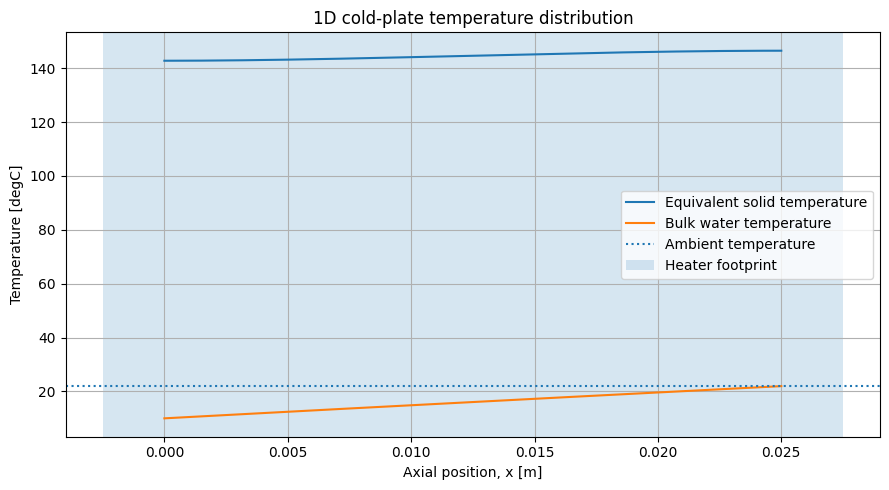

In [16]:
# Temperature plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, T_solid, label='Equivalent solid temperature')
ax.plot(x, T_water, label='Bulk water temperature')
ax.axhline(T_ambient_C, linestyle=':', label='Ambient temperature')
ax.axvspan(heater_center_x - heater_length/2,
           heater_center_x + heater_length/2,
           alpha=0.18, label='Heater footprint')
ax.set_xlabel('Axial position, x [m]')
ax.set_ylabel('Temperature [degC]')
ax.set_title('1D cold-plate temperature distribution')
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

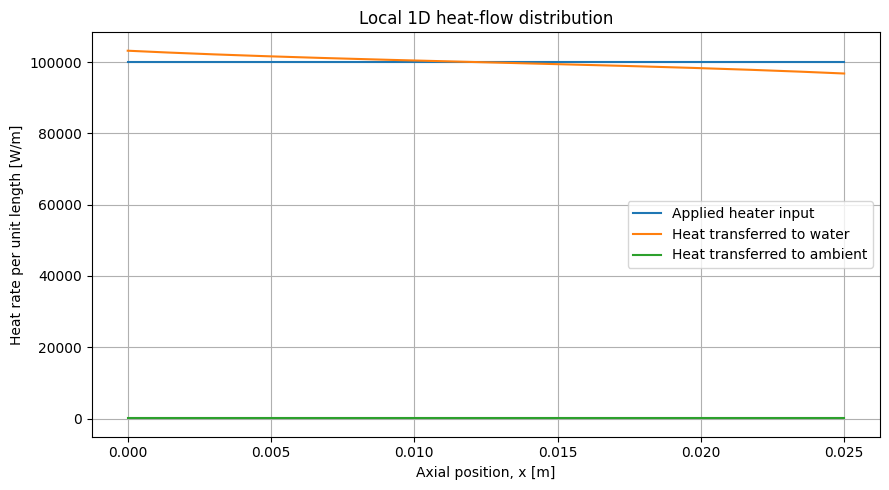

In [17]:
# Heat-flow plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, q_line, label='Applied heater input')
ax.plot(x, q_to_water_line, label='Heat transferred to water')
ax.plot(x, q_to_ambient_line, label='Heat transferred to ambient')
ax.set_xlabel('Axial position, x [m]')
ax.set_ylabel('Heat rate per unit length [W/m]')
ax.set_title('Local 1D heat-flow distribution')
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

## 5. Geometry calibration helpers

Use the Ansys velocity to infer total flow area, and use its pressure drop to
estimate an equivalent straight length for the selected rectangular channel.
These are diagnostics, not replacements for CAD dimensions.

In [18]:
area_inferred_from_ansys_velocity = m_dot_total / (rho_w * ansys_velocity_case3)
equivalent_length_from_ansys_dp = (
    ansys_dp_case3 * hydraulic_diameter /
    (f_D * 0.5 * rho_w * velocity**2)
)

print('Calibration diagnostics')
print(f'  Area inferred from 1.02 m/s = {area_inferred_from_ansys_velocity:.6e} m2')
print(f'  Current total flow area     = {flow_area_total:.6e} m2')
print(f'  Equivalent length for 795 Pa with current section = '
      f'{equivalent_length_from_ansys_dp:.4f} m')

Calibration diagnostics
  Area inferred from 1.02 m/s = 4.916711e-05 m2
  Current total flow area     = 7.158961e-05 m2
  Equivalent length for 795 Pa with current section = 0.0229 m


## Modelling notes

1. This is a reduced-order 1D steady model.
2. Properties are constant at the Ansys report values; no boiling is allowed.
3. The model assumes one-dimensional bulk flow and no flow maldistribution.
4. Pressure loss includes straight-wall friction only. Add inlet, outlet, bend,
   contraction, expansion, and manifold losses as K*rho*V^2/2 when known.
5. For multiple channels, `m_dot_total` is split equally and heat transfer uses
   the total wetted perimeter.
6. The 30 mm heater length is longer than the 25 mm modeled fluid path, so the
   complete 25 mm channel length receives a uniform share of the 600 W input.
7. The 4560 degC DesignExplore values in cases 1 and 2 likely represent failed or
   nonphysical designs. They are not used as calibration targets.
8. For temperature-dependent water properties, update rho, mu, k, and cp inside
   the iteration using a validated property package or tabulated data.